In [35]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Step 1: Create a simple binary classification dataset
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([0, 0, 0, 1, 1, 1])  # Target: 0 if x < 4, else 1

In [ ]:
# Normalize x for better training (optional, but helps)
x = (x - np.mean(x)) / np.std(x) # for making the datas small 

# see the below output all the datas are converted to -2 to 2
x

array([-1.46385011, -0.87831007, -0.29277002,  0.29277002,  0.87831007,
        1.46385011])

In [38]:
# Step 2: Define sigmoid and prediction functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict(x, w1, w0):
    z = w1 * x + w0
    return sigmoid(z)

In [39]:
# Step 3: Define binary cross-entropy loss
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15  # for numerical stability
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [40]:
# Step 4: Initialize weights and training params

w1, w0 = 0.0, 0.0 # weigth and bais
lr = 0.1 # Learning rate

epochs = 1000

losses = [] # use matplotlib for Visualization

In [43]:
# Step 5: Gradient Descent Training Loop
for epoch in range(epochs):
    y_pred = predict(x, w1, w0)
    loss = binary_cross_entropy(y, y_pred)
    losses.append(loss)
    
    # Gradients
    dw1 = np.dot((y_pred - y), x) / len(x)
    dw0 = np.sum(y_pred - y) / len(x)

    # Update weights
    w1 -= lr * dw1
    w0 -= lr * dw0


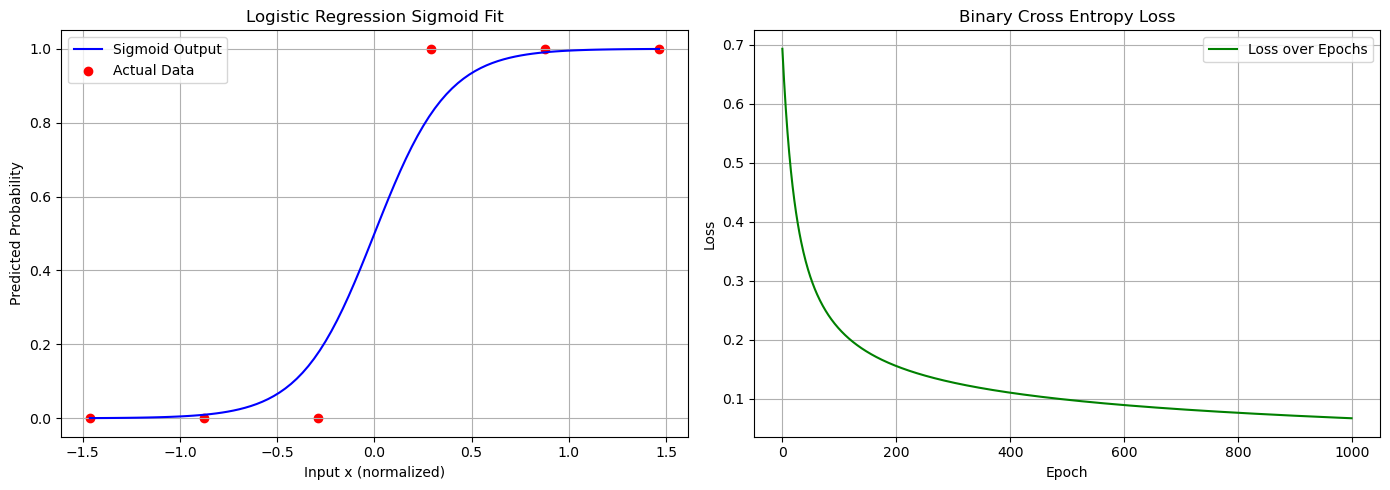

In [42]:
# Step 6: Plot sigmoid prediction curve
plt.figure(figsize=(14, 5))

# Plot 1: Sigmoid output over input
plt.subplot(1, 2, 1)
x_plot = np.linspace(min(x), max(x), 100)
y_plot = predict(x_plot, w1, w0)
plt.plot(x_plot, y_plot, label='Sigmoid Output', color='blue')
plt.scatter(x, y, color='red', label='Actual Data')
plt.title("Logistic Regression Sigmoid Fit")
plt.xlabel("Input x (normalized)")
plt.ylabel("Predicted Probability")
plt.legend()
plt.grid(True)

# Plot 2: Loss over training epochs
plt.subplot(1, 2, 2)
plt.plot(losses, label='Loss over Epochs', color='green')
plt.title("Binary Cross Entropy Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()